In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



df1 = pd.read_csv('One_year_compiled.csv')

# Ejercicio 1

In [2]:
df1.columns

Index(['timestamp', 'pCut::Motor_Torque',
       'pCut::CTRL_Position_controller::Lag_error',
       'pCut::CTRL_Position_controller::Actual_position',
       'pCut::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Actual_position',
       'pSvolFilm::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Lag_error', 'pSpintor::VAX_speed',
       'month', 'day', 'hour', 'sample_Number', 'mode'],
      dtype='str')

In [ ]:
df1.head()

In [ ]:
# pd.set_option('display.float_format', '{:.2f}'.format)
df1.describe().round(3)

# Ejercicio 3

In [3]:
df1_copia = df1.copy()
df1_copia

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,28,185909.0,518.0,mode2
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,28,185909.0,518.0,mode2
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,28,185909.0,518.0,mode2
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,28,185909.0,518.0,mode2


In [ ]:
df1_copia.iloc[500:751, 1:5]

# Ejercicio 8

In [ ]:
print(df1_copia.info())

In [ ]:
# df1_copia = sns.load_dataset('df1_copia')

"""
sns.histplot(
    data=df, x='col',
    bins=30,              # Número de bins
    binwidth=5,           # Ancho de cada bin (alternativa a bins)
    stat='count',         # count, frequency, probability, percent, density
    kde=True,             # Superponer curva KDE
    hue='category',       # Color por categoría
    multiple='layer',     # layer, dodge, stack, fill
    element='bars',       # bars, step, poly
    cumulative=False,     # Si True, histograma acumulado
    color='steelblue',    # Color cuando no hay hue
    palette='Set2',       # Paleta de colores cuando hay hue
    alpha=0.7,            # Transparencia
    linewidth=1,          # Grosor del borde
    ax=ax                 # Axes de Matplotlib donde dibujar
)  
"""


# Histograma con KDE por especie
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    bins=10,
    data=df1_copia,
    x='month',
    hue='mode',
    kde=True,
    stat='frequency',
    common_norm=False,
    alpha=0.6,
    ax=ax
)
ax.set_title('frecuencia tiempo en meses')
ax.set_xlabel('meses')
ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

In [4]:
# quitar decimales en las columnas 8 y 9

df1_copia = np.round(df1_copia, 2)


In [5]:
df1_copia['pSpintor::VAX_speed'] = np.round(df1_copia['pSpintor::VAX_speed'], 2)
df1_copia['pSpintor::VAX_speed']

0          1380.0
1          1380.0
2          1380.0
3          1380.0
4          1380.0
            ...  
1062907    1500.0
1062908    1500.0
1062909    1500.0
1062910    1500.0
1062911    1500.0
Name: pSpintor::VAX_speed, Length: 1062912, dtype: float64

In [ ]:
# pasar la columna hora a otro formato

# df1_copia['hour'] = df1_copia['hour'].astype(int).astype(str).str.zfill(6)

# df1_copia['hour'] = df1_copia['hour'].str.replace(r'(\d{2})(\d{2})(\d{2})', r'\1/\2/\3', regex=True)

# df1_copia


In [ ]:
# pasar mode a numérico

# df1_copia['mode'] = df1_copia['mode'].str.replace('Pepe', 'José', regex=False)

In [6]:
# Para responder la pregunta 3, necesitamos hacer una correlación de Pearson

matriz_correlacion = np.corrcoef(df1_copia['pCut::CTRL_Position_controller::Actual_speed'], df1_copia['pSvolFilm::CTRL_Position_controller::Actual_speed'])
matriz_correlacion[0, 1]

#  mostrar:
print(f"La sincronización entre film y corte es de: {matriz_correlacion[0, 1]}")

La sincronización entre film y corte es de: -0.3410932175678699


## 1. Definimos los umbrales (variables) según el "conocimiento experto"

umbral_averia_motor = 1
umbral_averia_film = 2

#1.- Creamos las columnas de avería para cada sensor, para ver cuál de los dos es el que está dando el problema.
df1_copia['Averia_Motor'] = (df1_copia['pCut::CTRL_Position_controller::Lag_error'].abs() >= umbral_averia_motor).astype(int)
df1_copia['Averia_Film'] = (df1_copia['pSvolFilm::CTRL_Position_controller::Lag_error'].abs() >= umbral_averia_film).astype(int)

## columna unificada

## La Avería Total es 1 si cualquiera de las dos averías específicas ocurre
df1_copia['Averia_Total'] = ((df1_copia['Averia_Motor'] == 1) | (df1_copia['Averia_Film'] == 1)).astype(int)

Esta fue la creación de columnas que hice yo, pero utilizaremos las de Ángel

In [7]:
# gráficas columnas 1 y 2

df1_copia["averia"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["averia"].value_counts()

df1_copia["s1"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7)
).astype(int)

df1_copia["s1"].value_counts()

df1_copia["s2"] = (
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) | (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["s2"].value_counts()


s2
0    1050939
1      11973
Name: count, dtype: int64

In [8]:
# Filtramos los datos para el caso 3: que exista error en S1, y no en S2
df_caso3 = df1_copia[(df1_copia['s1'] == 1) & (df1_copia['s2'] == 0)]

# https://cursos.kobalto.es/teoria/python-sintaxis#method=len_func

print(f"Número de registros con error solo en S1: {len(df_caso3)}")


Número de registros con error solo en S1: 447642


C:\Users\kityh\AppData\Local\Temp\ipykernel_29684\1037160748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')


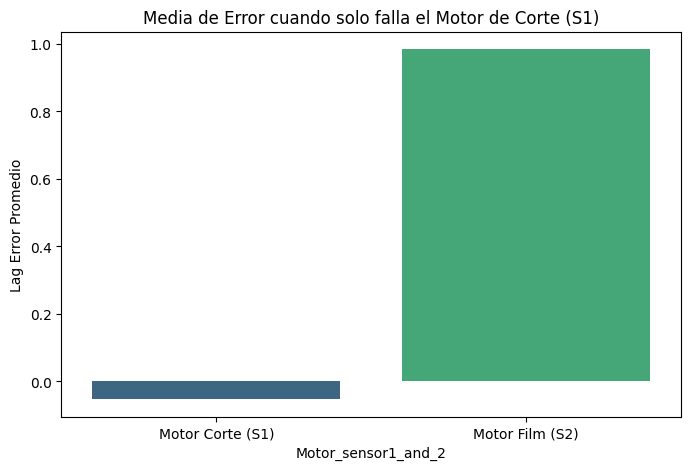

In [9]:
# 2. Preparamos los datos para Seaborn (necesitamos un formato largo)
# Creamos un mini dataframe para la gráfica
# df_caso3= df1_copia[(df1_copia['s1'] == 1) & (df1_copia['s2'] == 0)]

# https://cursos.kobalto.es/teoria/pandas-advanced#method=reset_index

data_plot = df_caso3[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
data_plot.columns = ['Motor_sensor1_and_2', 'Error_Medio']

# 3. Dibujamos siguiendo un barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=data_plot, x='Motor_sensor1_and_2', y='Error_Medio', palette='viridis')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

# PCA Y PREPROCESAMIENTO PARA EL PUNTO 5

In [10]:
# Definimos el orden de los modos para que sean números
orden_modos = ['mode0', 'mode1', 'mode2', 'mode3', 'mode4', 'mode5', 'mode6', 'mode7', 'mode8']
df1_copia['mode'] = df1_copia['mode'].map({modo: i for i, modo in enumerate(orden_modos)})

# Creamos la X definitiva quitando lo que NO son sensores
# Usamos errors='ignore' por si ya habías borrado alguna antes
columnas_sobran = ['averia', 's1', 's2', 'timestamp', 'sample_Number']
X = df1_copia.drop(columns=columnas_sobran, errors='ignore')

# Limpiamos cualquier valor nulo que haya quedado para evitar errores en el PCA
X = X.dropna()
y_s1 = df1_copia.loc[X.index, 's1'] # Aseguramos que 'y' tenga las mismas filas que 'X'


In [ ]:
# Aquí está todo lo que necesitas en una sola pieza
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),       # Paso 1: Escalado automático
    ('pca', PCA(n_components=0.90)),    # Paso 2: PCA al 90% automático
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)) # Paso 3: Clasificador
])

# 3. Entrenamiento y Evaluación para S1
X_train, X_test, y_train, y_test = train_test_split(X, y_s1, test_size=0.2, random_state=42)

print("Entrenamiento modelo para motor torque S1.")
pipeline_final.fit(X_train, y_train)

# Resultado final
y_pred = pipeline_final.predict(X_test)
print("\n" + "="*60)
print("--- RESULTADOS FINALES PARA S1 --- ")
print("="*60)

print(classification_report(y_test, y_pred))

Entrenamiento modelo para motor torque S1.

--- RESULTADOS FINALES PARA S1 ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96    121872
           1       0.96      0.95      0.95     90711

    accuracy                           0.96    212583
   macro avg       0.96      0.96      0.96    212583
weighted avg       0.96      0.96      0.96    212583



In [14]:
# 1. Definimos el nuevo objetivo (y) para s2
# Usamos el mismo índice de X por si hubo limpieza de nulos
y_s2 = df1_copia.loc[X.index, 's2']

# 2. Dividimos los datos (importante hacer un nuevo split para s2)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X, y_s2, test_size=0.2, random_state=42
)

# 3. Entrenamos el MISMO pipeline pero con los datos de s2
# El pipeline se reinicia internamente al llamar a .fit()
print("Iniciando entrenamiento para el Motor Film (S2)...")
pipeline_final.fit(X_train_s2, y_train_s2)

# 4. Resultados para s2
y_pred_s2 = pipeline_final.predict(X_test_s2)

print("\n" + "="*60)
print(" --- RESULTADOS FINALES PARA S2 --- ")
print("="*60)
print(classification_report(y_test_s2, y_pred_s2))

Iniciando entrenamiento para el Motor Film (S2)...

 --- RESULTADOS FINALES PARA S2 --- 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    210211
           1       0.97      0.95      0.96      2372

    accuracy                           1.00    212583
   macro avg       0.98      0.97      0.98    212583
weighted avg       1.00      1.00      1.00    212583

